# Tail frames for the mountain aircraft — twin booms against a single tail (34)

*A structural comparison study, with each variant's aerodynamic efficiency and its speed and acceleration marked beside
the structure. It prepares FALCO, the tractor redesign (a large propeller, a simple tail, more efficiency), and it
answers whether NISUS+ itself could carry the large propeller as a pusher between booms moved apart.*

**The base** is NISUS+ (notebook 33): the 2.4 m twin-boom pusher, 20/18 carbon booms 500 mm apart in printed root
fittings on the wing's two carry-through tubes, an H-tail on the booms, the APC 15x8 between them.

**The variants**, all on NISUS+'s wing, pod and tail arm with the tail volume coefficients kept (the same stability):

| variant | what changes |
|---|---|
| `twin 15"` | NISUS+ as built |
| `twin 18"`, `twin 20"`, `twin 22"` | the booms moved apart for the larger pusher at the same propeller clearance; the stabiliser spans the booms (its chord shrinks to keep the area), the rear tube reaches the fittings and is resized, the flaps start outboard of the fittings |
| `single 20"` | one roll-wrapped tail tube out of the pod's tail cone to a conventional tail of the same volumes — the tractor's frame (a pusher cannot have it: its propeller sits where the tube goes) |

**The method** (`designs/frame_study.py`): the frames by hand (bending, torsion with each tube's own shear modulus,
the first mode) and in Talos (the frame's carbon members: the tubes, the stabiliser's spar tying them, a rod per fin
carrying the side load in at the fin's aerodynamic centre; two ultimate cases — the symmetric pull-out with the fins'
side load, and the asymmetric one, the stabiliser's lift on one half only — and the first modes with the tail's masses
lumped); what the tail puts into the wing (NISUS+'s hand checks of the spar and the rear tube at the boom fittings);
the aerodynamics (NISUS+'s drag build-up for each frame, the aircraft's Cd0, L/D, the cruise power, the mission's
energy, the propeller's efficiency); speed and acceleration (the level top speed, the acceleration at the launch and
cruise speeds, 15 → 25 m/s, the best climb) with each propeller on a motor of the AT4125's power class wound for it.

Two caveats, marked where they bite: the FEA material is isotropic (G = 46 GPa), so its torsional numbers for a
unidirectional tube are optimistic (the hand table uses G 5 GPa pultruded / 20 GPa roll-wrapped); and the larger
propellers are the 15x8's generic planform scaled (the real blades are not in the model), on an assumed motor.

`FRAME_FEA=0` skips the FEA (NOT RUN).

In [1]:
import json, math, os, sys, time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from vegeta import talos, cache
sys.path.insert(0, "designs")
import frame_study as fst
import nisus_plus as npl, nisus_plus_systems as fs, nisus_plus_flight as ff, nisus_plus_structure as st

pd.set_option("display.max_colwidth", 110); pd.set_option("display.width", 220)
ROOT = Path("_runs/frame_study"); ROOT.mkdir(parents=True, exist_ok=True)
OUT = Path("output") / "34_frame_study"; OUT.mkdir(parents=True, exist_ok=True)
for sub in ("tables", "plots"):
    (OUT / sub).mkdir(exist_ok=True)
cache.notebook("34_frame_study")
RUN_FEA = os.environ.get("FRAME_FEA", "1") != "0"
STATUS = {}
def save_table(df, name):
    df.to_csv(OUT / "tables" / f"{name}.csv")
    return df
print("FEA", "on" if RUN_FEA else "NOT RUN")

FEA on


## Part 1 — the variants

The booms move apart so that the larger propeller keeps NISUS+'s clearance to them (measured in the propeller's
plane; the booms sit 68 mm below the axis). Everything the spacing touches follows: the stabiliser's span (its chord
shrinks to keep the area, the fins keep theirs at that chord), the rear carry-through tube (50 mm past the fittings,
resized by hand for the longer arm to the pod), the flaps (10 mm outboard of the fittings: crow loses span). A
variant is **rejected** when the wing's main spar fails its tail-case check (the booms' reactions bend it at the pod's
side) — the spar is the wing's, and growing it for the booms is another aircraft.

,feasible,propeller,kind,booms apart [mm],tube,stabiliser [mm],fins [mm],rear tube,flap span [mm],note
"twin 15""",True,15x8,twin,500.0,2 x 20/18 pultruded,560 x 190,2 x 310 x 190 (110 ventral),18/14 x 600,260.0,
"twin 18""",True,18x10,twin,578.597388,2 x 20/18 pultruded,639 x 167,2 x 354 x 167 (125 ventral),20/16 x 679,220.701306,
"twin 20""",False,20x13,twin,630.668822,2 x 20/18 pultruded,691 x 154,2 x 382 x 154 (136 ventral),22/18 x 731,194.665589,the main spar's tail-case margin -0.10: the wing's spar would have to grow for the booms
"twin 22""",False,22x12,twin,682.548656,2 x 20/18 pultruded,743 x 143,2 x 411 x 143 (146 ventral),25/21 x 783,168.725672,the main spar's tail-case margin -0.21: the wing's spar would have to grow for the booms
"single 20""",True,20x13,single,NaN,1 x 30/28 roll-wrapped,560 x 190,1 x 413 x 285,18/14 x 600,260.0,the tractor's frame: the tube leaves the pod where the pusher's propeller is


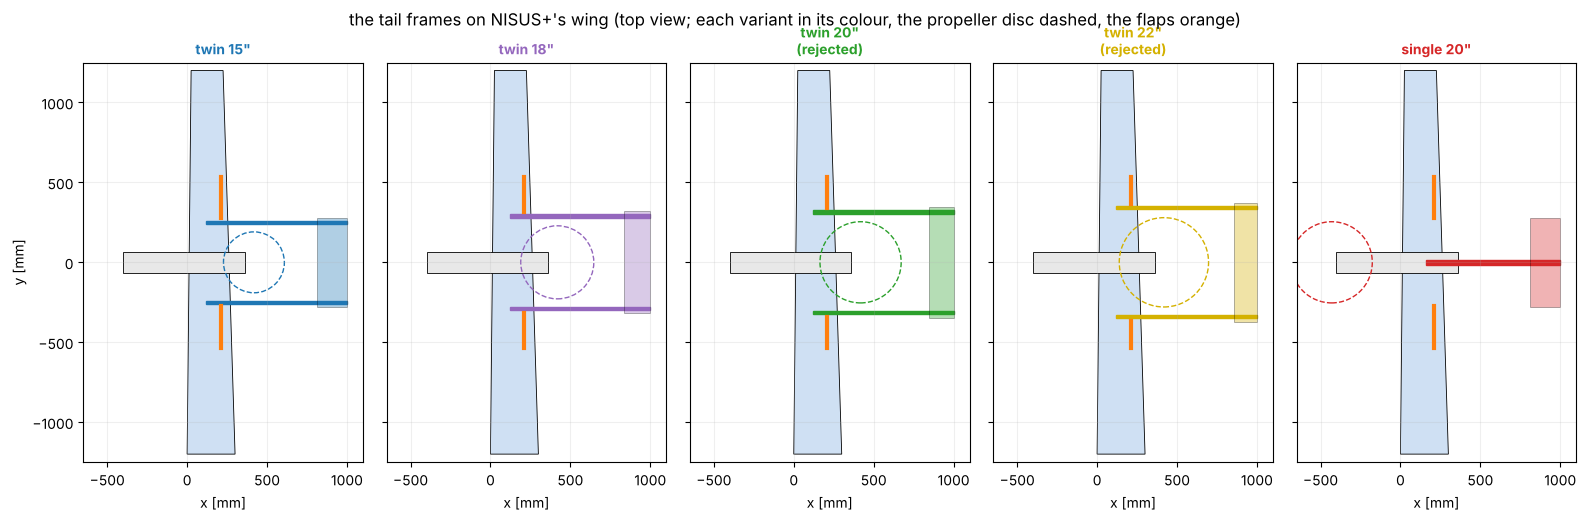

In [2]:
P = npl.resolve()
F = fst.frames(P)
FT = pd.DataFrame({f.name: {"feasible": f.feasible, "propeller": f"{f.prop_in:g}x{f.pitch_in:g}", "kind": f.kind, "booms apart [mm]": 2 * f.boom_y if f.kind == "twin" else np.nan,
                            "tube": f"{f.n_tubes} x {f.tube_od:g}/{f.tube_id:g} {f.tube_kind}", "stabiliser [mm]": f"{f.tail_span:.0f} x {f.tail_chord:.0f}",
                            "fins [mm]": f"{f.n_fins} x {f.fin_height:.0f} x {f.fin_chord:.0f}" + (f" ({f.fin_ventral:.0f} ventral)" if f.fin_ventral else ""),
                            "rear tube": f"{f.rear_spar_od:g}/{f.rear_spar_id:g} x {2 * f.rear_spar_half_length:.0f}", "flap span [mm]": P["flap_y1"] - f.flap_y0, "note": f.note} for f in F}).T
display(save_table(FT, "variants"))
fig = fst.sketch(F, P); fig.savefig(OUT / "plots" / "frames.png", dpi=110); plt.show()

## Part 2 — the frames by hand

The ultimate loads are NISUS+'s (notebook 33, Part 8): the stabiliser's maximum lift and the fins' side load at
V_NE, x 1.5. Per tube: the bending stress and margin at the socket's exit, the tip deflection and the stabiliser's
incidence change under the pull-out (control effectiveness), the fin's twist under its side load (the twin's fins
straddle the boom, so their side load's centroid is near the axis; the single tail's fin is all above the tube), the
tail's roll under the asymmetric case — the twin carries it as **differential bending** of two booms, the single tube
as **torsion** — and the first bending frequency with the tail mass at the tip.

,"twin 15""","twin 18""","twin 20""","twin 22""","single 20"""
feasible,True,True,False,False,True
propeller [in],15.0,18.0,20.0,22.0,20.0
booms apart [mm],500.0,578.597388,630.668822,682.548656,NaN
tube,2 x 20/18 pultruded,2 x 20/18 pultruded,2 x 20/18 pultruded,2 x 20/18 pultruded,1 x 30/28 roll-wrapped
cantilever [mm],569.446903,589.59386,600.743077,610.537228,497.5
tail span x chord [mm],560 x 190,639 x 167,691 x 154,743 x 143,560 x 190
fins,2 x 310 high,2 x 354 high,2 x 382 high,2 x 411 high,1 x 413 high
"bending stress, ultimate [MPa]",150.662761,155.99319,158.943021,161.534331,111.229276
margin (500 MPa x 0.8),1.654936,1.564215,1.516625,1.476254,2.596176
tip deflection at ultimate [mm],9.096414,10.096465,10.680137,11.211067,3.417211


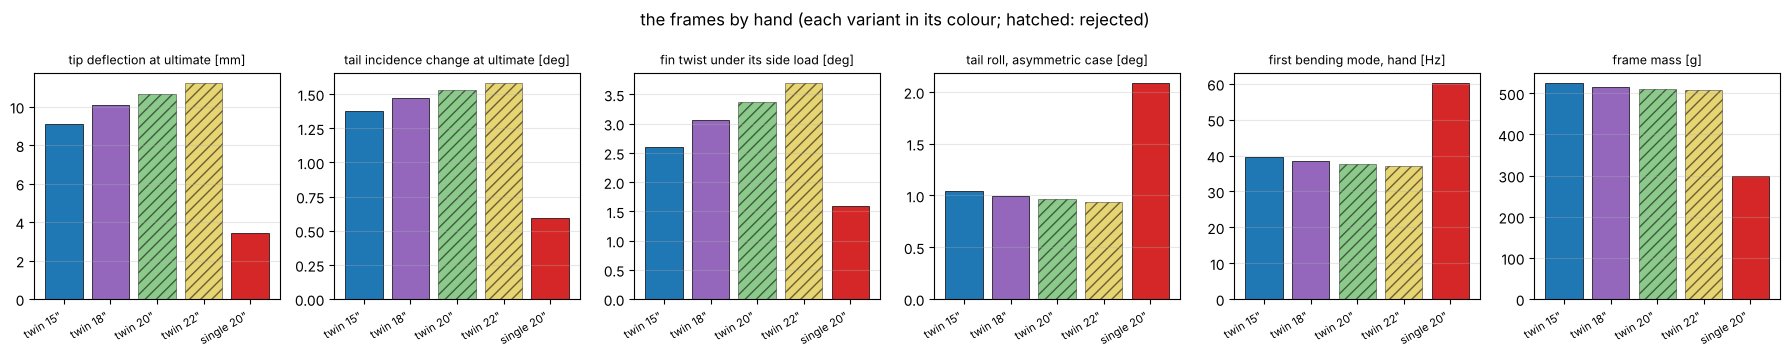

In [3]:
HAND = fst.hand_table(F, P)
display(save_table(HAND.T, "hand"))
cols = ["tip deflection at ultimate [mm]", "tail incidence change at ultimate [deg]", "fin twist under its side load [deg]", "tail roll, asymmetric case [deg]", "first bending mode, hand [Hz]", "frame mass [g]"]
fig, ax = plt.subplots(1, len(cols), figsize=(18, 3.6))
for a, c in zip(ax, cols):
    fst.bars(a, HAND[c], F); a.set_title(c, fontsize=9)
fig.suptitle("the frames by hand (each variant in its colour; hatched: rejected)"); fig.tight_layout(); fig.savefig(OUT / "plots" / "hand.png", dpi=110); plt.show()

## Part 3 — the frames in Talos

The carbon members of `twin 15"`, `twin 20"` and `single 20"` (the 18" and 22" booms are the same tubes at another
spacing: hand only): case **A**, the symmetric pull-out with the fins' side load; case **B**, the asymmetric one (the
left half's lift only); then the first modes with the tail's masses lumped on the spar, the fin rods and the tubes'
ends. The nominal stress leaves out the clamped socket and the load points. The tail's motion is read at the tubes:
the heave, the roll (the twin: the booms' differential heave; the single: the tube's twist — **isotropic G**, so
optimistic by √(46/20) ≈ 1.5 for the roll-wrapped tube and the fin's yaw) and the fin's yaw twist.

In [4]:
CASES = fst.fea_models(F, ROOT, P)
t0 = time.time()
RES = fst.solve_cases(CASES, ROOT, run=RUN_FEA, progress=True)      # one bar over the cases; its postfix Talos' stage
FEAT = fst.fea_table(CASES, RES, P)
MODES = fst.modes_table(CASES, RES)
STATUS["FEA"] = "run" if (FEAT["status"] == "solved").any() else "NOT RUN"
print(f"{STATUS['FEA']} ({time.time() - t0:.0f} s)")
display(save_table(FEAT.T, "fea"))
display(save_table(MODES.T, "modes"))

frames FEA: 0/9 |          | 00:00 

run (799 s)


case,twin_15in_A,twin_15in_B,twin_20in_A,twin_20in_B,single_20in_A,single_20in_B
status,solved,solved,solved,solved,solved,solved
description,"twin 15"": symmetric pull-out: stabiliser 96 N up, fins 53 N side each (ultimate)","twin 15"": asymmetric: the left half's 48 N only, fins 53 N side (ultimate)","twin 20"": symmetric pull-out: stabiliser 96 N up, fins 53 N side each (ultimate)","twin 20"": asymmetric: the left half's 48 N only, fins 53 N side (ultimate)","single 20"": symmetric pull-out: stabiliser 96 N up, fins 106 N side each (ultimate)","single 20"": asymmetric: the left half's 48 N only, fins 106 N side (ultimate)"
peak von Mises [MPa],257.334703,189.315711,291.187097,207.139843,131.382154,136.42854
nominal von Mises [MPa],148.95558,132.349866,157.002035,141.180291,109.18166,93.386341
99.5th percentile von Mises [MPa],138.734059,119.733755,147.41141,126.879506,104.175456,89.679355
max displacement [mm],19.18454,17.010213,23.121587,18.805173,10.435228,9.932367
allowable [MPa],400.0,400.0,400.0,400.0,400.0,400.0
margin (governing),1.685364,2.022292,1.547738,1.833257,2.663619,3.283282
governing stress,nominal (≥ 1 diameter from the support),nominal (≥ 1 diameter from the support),nominal (≥ 1 diameter from the support),nominal (≥ 1 diameter from the support),nominal (≥ 1 diameter from the support),nominal (≥ 1 diameter from the support)
reaction [N],142.92388,116.378777,142.92388,116.378777,142.92388,116.378777


,"twin 15""","twin 20""","single 20"""
status,solved,solved,solved
mode 1 [Hz],26.55874,25.3352,42.32552
mode 2 [Hz],28.43733,26.95122,43.18032
mode 3 [Hz],32.00334,29.47911,84.70187
mode 4 [Hz],106.9341,76.42211,129.7759
mode 5 [Hz],110.3861,76.64907,137.4266
torsion note,isotropic G 46 GPa: a torsional mode is optimistic x 3.0,isotropic G 46 GPa: a torsional mode is optimistic x 3.0,isotropic G 46 GPa: a torsional mode is optimistic x 1.5


## Part 4 — what the tail puts into the wing

With twin booms the tail's loads enter the wing through the boom fittings and bend the main spar and the rear
carry-through tube at the pod's side (the tail case of notebook 33's joint checks): the arm grows with the spacing.
With a single tail the spars see only the lift; the tube's root moment goes into the pod's keel socket and the saddle
instead. The flap span left for crow is marked: the booms' fittings push the flaps outboard.

In [5]:
WING = fst.wing_loading(F, P)
display(save_table(WING.T, "wing_loading"))

,"twin 15""","twin 18""","twin 20""","twin 22""","single 20"""
booms apart [mm],500.0,578.597388,630.668822,682.548656,NaN
arm from the pod's side [mm],180.0,219.298694,245.334411,271.274328,NaN
rear tube,18/14 x 600,20/16 x 679,22/18 x 731,25/21 x 783,18/14 (NISUS+'s: no tail load on it)
"main spar: bending from the boom, tail case [MPa]",300.493288,386.452605,445.788377,506.768711,0.0
main spar margin,0.331145,0.035056,-0.102713,-0.210685,NaN
rear tube: bending at the pod side [MPa],342.404446,343.545071,317.899993,270.198709,0.0
rear tube margin,0.168209,0.16433,0.258257,0.480392,NaN
boom socket: bearing at the exit [N],280.199363,295.950013,305.363756,314.203544,272.378673
flap span left [mm],260.0,220.701306,194.665589,168.725672,260.0
crow drag kept [%],100.0,84.885118,74.87138,64.894489,100.0


## Part 5 — aerodynamic efficiency, marked for each variant

The frame's wetted area and parasite drag area by NISUS+'s build-up at the cruise Reynolds numbers (3000 m), the
aircraft's Cd0 with that frame (NISUS+'s own frame share swapped out), its mass, L/D max, the cruise power at 18 m/s
EAS, the mission's energy and the feasible survey time (NISUS+'s mission plan), and the propeller's efficiency at
cruise and in the full-throttle climb. Each propeller is the 15x8's generic planform scaled (APC's 18x10E, 20x13E,
22x12E sizes; the real blades are not in the model) on a motor of the AT4125's power class wound for it — the same
resistance and current limit, KV chosen for the published full-throttle current (an assumption: a larger stator,
~50-100 g more, not charged here).

propeller maps (Boreas, ~400 solves each):   0%|          | 0/4 [00:00<?, ?it/s]

,motor,KV,static thrust [N],thrust at 20 m/s [N],thrust at 30 m/s [N],"η at 20 m/s, 20 N"
15x8,T-Motor AT4125 KV540 (fitted),540.0,55.329232,34.032135,20.591914,0.668137
18x10,AT4125-class KV392,391.854445,62.235376,35.258304,18.19838,0.697898
20x13,AT4125-class KV310,309.998513,65.131493,38.115132,20.189022,0.734443
22x12,AT4125-class KV283,282.579365,71.39066,34.408551,11.266903,0.702248


,"twin 15""","twin 18""","twin 20""","twin 22""","single 20"""
feasible,True,True,False,False,True
propeller,15x8,18x10,20x13,22x12,20x13
frame wetted area [m²],0.521456,0.524395,0.525974,0.527326,0.49978
frame drag area [m²],0.003857,0.003968,0.004035,0.004098,0.003574
aircraft Cd0,0.026465,0.02665,0.026762,0.026867,0.025994
mass [kg],5.309971,5.301586,5.297214,5.293565,5.084175
L/D max,16.013407,15.957158,15.923302,15.891786,16.158056
"cruise power at 18 EAS, 3000 m [W]",160.103638,164.677953,153.830941,181.821491,149.225035
propeller η at cruise,0.668025,0.651473,0.703416,0.589711,0.698712
propeller η in the climb (full throttle),0.579062,0.621387,0.648559,0.661373,0.648559


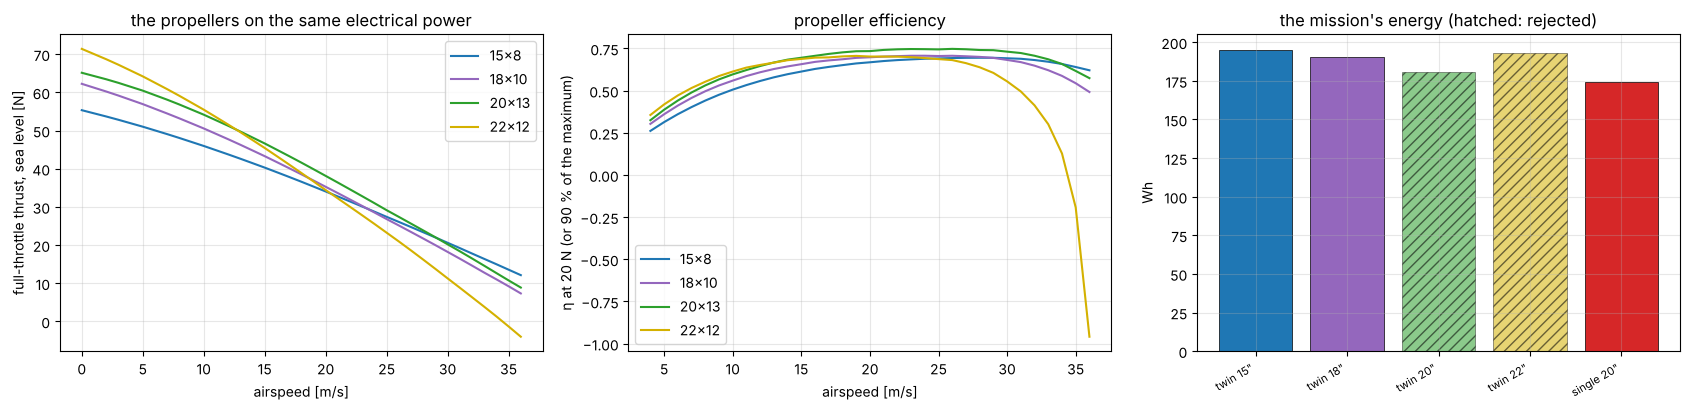

In [6]:
from tqdm.auto import tqdm
DRIVES = {}
for d in tqdm(sorted({f.prop_in for f in F}), desc="propeller maps (Boreas, ~400 solves each)"):
    DRIVES[d] = fst.drive_for_prop(d)
PT = pd.DataFrame({f"{d:g}x{fst.PROPS[d]:g}": {"motor": dr.motor_name, "KV": dr.kv, "static thrust [N]": dr.max_thrust(0.0), "thrust at 20 m/s [N]": dr.max_thrust(20.0),
                                                "thrust at 30 m/s [N]": dr.max_thrust(30.0), "η at 20 m/s, 20 N": fst._prop_eta(dr, 20.0, 20.0, fs.RHO0)} for d, dr in DRIVES.items()}).T
display(save_table(PT, "propellers"))
AERO = fst.aero_table(F, P, drives=DRIVES)
display(save_table(AERO.T, "aero"))
fig, ax = plt.subplots(1, 3, figsize=(17, 4.2))
V = np.linspace(0, 36, 37)
for d, dr in DRIVES.items():
    ax[0].plot(V, [dr.max_thrust(v) for v in V], color=fst.PROP_COLORS[d], label=f"{d:g}x{fst.PROPS[d]:g}")
    ax[1].plot(V[4:], [fst._prop_eta(dr, v, min(20.0, 0.9 * dr.max_thrust(v)), fs.RHO0) for v in V[4:]], color=fst.PROP_COLORS[d], label=f"{d:g}x{fst.PROPS[d]:g}")
ax[0].set(xlabel="airspeed [m/s]", ylabel="full-throttle thrust, sea level [N]", title="the propellers on the same electrical power"); ax[0].legend()
ax[1].set(xlabel="airspeed [m/s]", ylabel="η at 20 N (or 90 % of the maximum)", title="propeller efficiency"); ax[1].legend()
fst.bars(ax[2], AERO["mission energy [Wh]"], F)
ax[2].set(ylabel="Wh", title="the mission's energy (hatched: rejected)")
for a in ax: a.grid(alpha=0.3)
fig.tight_layout(); fig.savefig(OUT / "plots" / "aero.png", dpi=110); plt.show()

## Part 6 — speed and acceleration

With each variant's Cd0 and mass and its propeller's map, at the meadow (1200 m) and at 3000 m: the level top speed
at full throttle (and whether V_NE = 35 m/s EAS caps it), the acceleration in level flight at full throttle at the
launch speed (17 m/s) and at the cruise speed, the time from 15 to 25 m/s TAS, the best climb rate.

,"twin 15""","twin 18""","twin 20""","twin 22""","single 20"""
feasible,True,True,False,False,True
propeller,15x8,18x10,20x13,22x12,20x13
"static thrust, sea level [N]",55.329232,62.235376,65.131493,71.39066,65.131493
"top speed, level [m/s TAS] @1200 m",36.126044,34.169574,34.800771,30.986807,34.938418
top speed capped by V_NE @1200 m,False,False,False,False,False
acceleration at launch 17 m/s [m/s²] @1200 m,6.004719,6.427127,7.00027,6.602555,7.323988
acceleration at cruise 19 m/s TAS [m/s²] @1200 m,5.467105,5.757222,6.292746,5.724002,6.58711
15 → 25 m/s [s] @1200 m,2.0,1.9,1.75,2.0,1.65
best climb [m/s] @1200 m,10.642815,11.219965,12.249961,11.451422,12.821077
"top speed, level [m/s TAS] @3000 m",36.667056,34.628894,35.280603,31.343684,35.415714


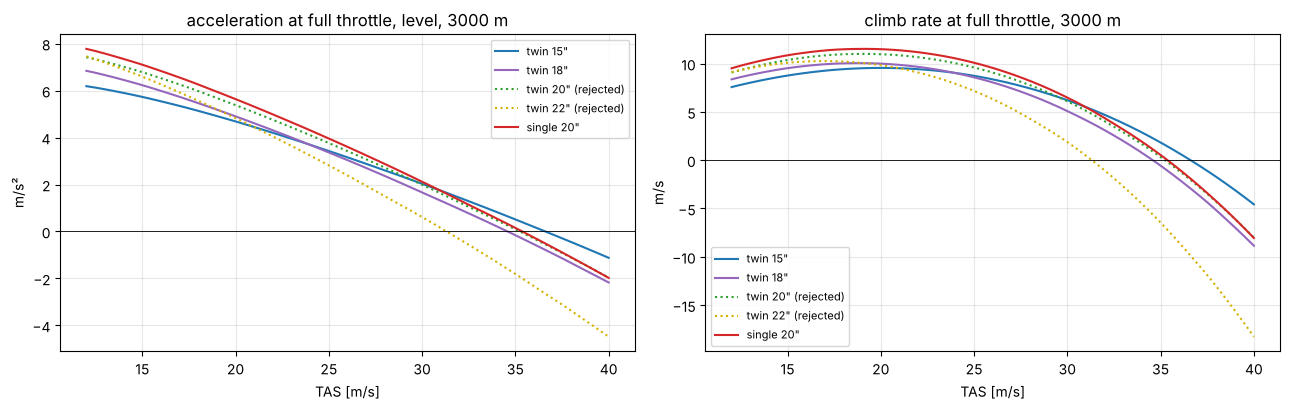

In [7]:
PERF = fst.performance_table(F, P, drives=DRIVES)
display(save_table(PERF.T, "performance"))
fig, ax = plt.subplots(1, 2, figsize=(13, 4.2))
atm = fs.atmosphere(3000.0); rho = atm["rho"]
af0 = ff.airframe(fs.DEFAULT_PACK, P, h_m=3000.0); S = af0.wing_area_m2
base = fst._base_frame_cd_area(P, 3000.0) / S; m_base = fst.frame_mass(fst.twin_frame(P, 15.0, fit_rear_tube=False), P)["frame [g]"]
V = np.linspace(12, 40, 60)
for f in F:
    cd0 = af0.cd0 - base + fst.frame_drag(f, P, 3000.0)["cd_area_m2"] / S
    m = af0.mass_kg + (fst.frame_mass(f, P)["frame [g]"] - m_base) * 1e-3
    dr = DRIVES[f.prop_in]
    T = np.array([dr.max_thrust(v, rho) for v in V]); D = np.array([fs._drag(m, cd0, af0.aspect_ratio, af0.oswald, S, v, rho) for v in V])
    ax[0].plot(V, (T - D) / m, color=fst.color(f.name), label=f.name + ("" if f.feasible else " (rejected)"), ls="-" if f.feasible else ":")
    ax[1].plot(V, (T - D) * V / (m * fs.G), color=fst.color(f.name), label=f.name + ("" if f.feasible else " (rejected)"), ls="-" if f.feasible else ":")
ax[0].axhline(0, color="k", lw=0.6); ax[0].set(xlabel="TAS [m/s]", ylabel="m/s²", title="acceleration at full throttle, level, 3000 m"); ax[0].legend(fontsize=8)
ax[1].axhline(0, color="k", lw=0.6); ax[1].set(xlabel="TAS [m/s]", ylabel="m/s", title="climb rate at full throttle, 3000 m"); ax[1].legend(fontsize=8)
for a in ax: a.grid(alpha=0.3)
fig.tight_layout(); fig.savefig(OUT / "plots" / "performance.png", dpi=110); plt.show()

## Part 7 — the verdict

In [8]:
VERDICT = fst.verdict(HAND, WING, AERO, PERF)
for k, v in VERDICT["widening"].items():
    print(f"{k:10s} feasible {v['feasible']!s:5s}  booms {v['booms apart [mm]']:.0f} mm  rear tube {v['rear tube']:14s} crow {v['crow drag kept [%]']:.0f} %  "
          f"frame {v['frame mass [g]']:.0f} g  Cd0 {v['Cd0']:.4f}  mission {v['mission energy [Wh]']:.0f} Wh  {v['note']}")
print()
for k, v in VERDICT["single vs twin"].items():
    if k != "against":
        print(f"{k:32s} single {v[0]:9.3f}   {VERDICT['single vs twin']['against']} {v[1]:9.3f}")

twin 18"   feasible True   booms 579 mm  rear tube 20/16 x 679    crow 85 %  frame 516 g  Cd0 0.0267  mission 190 Wh  
twin 20"   feasible False  booms 631 mm  rear tube 22/18 x 731    crow 75 %  frame 511 g  Cd0 0.0268  mission 181 Wh  the main spar's tail-case margin -0.10: the wing's spar would have to grow for the booms
twin 22"   feasible False  booms 683 mm  rear tube 25/21 x 783    crow 65 %  frame 508 g  Cd0 0.0269  mission 193 Wh  the main spar's tail-case margin -0.21: the wing's spar would have to grow for the booms

frame mass [g]                   single   298.323   twin 20"   511.362
frame drag area [m²]             single     0.004   twin 20"     0.004
L/D max                          single    16.158   twin 20"    15.923
mission energy [Wh]              single   174.381   twin 20"   180.738
tail roll, asymmetric [deg]      single     2.083   twin 20"     0.970
fin twist [deg]                  single     1.584   twin 20"     3.376
first bending mode [Hz]          single 

### Moving NISUS+'s booms apart for a large pusher: no

- **18" (booms 579 mm apart)** is as far as the wing allows: the rear tube grows to 20/16, the main spar's tail-case
  margin falls to +0.03, crow keeps 85 % of its flap span. The 18x10 earns 2.6 % of the mission's energy and
  +0.5 m/s of climb — a propeller change, not a frame change, and not worth the spar at its limit.
- **20" and 22" are rejected**: the booms' reactions bend the main spar past its allowable in the tail case
  (margins −0.10 and −0.21: the wing's spar would have to grow for the booms), the rear tube goes to 22/18 and 25/21
  (the boom fitting's web problem of notebook 33 again), crow drops to 75 % and 65 % of its drag, the stabiliser
  spans 690-740 mm on a 143-154 mm chord. The frame gets no stiffer for it (the booms are the same tubes on a longer
  cantilever: the tip deflection grows 9 → 11 mm). The 22x12's pitch even loses at cruise (η 0.59).

The twin-boom frame carries its tail well — a 1.5 bending margin, the asymmetric gust taken as differential bending
(1.0° of roll), 39 Hz — but it charges the wing for it: every millimetre of boom spacing is arm on the spar and the
rear tube at the pod's side, and flap span lost to the fittings. The large propeller belongs with a tractor.

### The single tail for FALCO: yes, as a roll-wrapped tube

Against the twin frame at the same propeller (`twin 20"`): **213 g lighter** (one tube and two root fittings fewer),
a 2.6 bending margin (1.5), a third of the tip deflection (3.4 vs 10.7 mm at ultimate: 0.6° vs 1.5° of stabiliser
incidence), a first bending mode at 60 Hz (38), **nothing in the wing's spars** (0 vs 448 MPa in the tail case: the
tube's 54 N m root moment goes into the pod's keel socket and the saddle). Its one weakness is torsion: the
asymmetric gust rolls the tail 2.1° (the twin's 1.0°) and the fin twists 1.6° under its side load **with a
roll-wrapped tube (G ~20 GPa)** — a pultruded tube (G ~5 GPa) would give four times that: the single tail's tube must
be roll-wrapped, and its stabiliser needs its own 12/10 cantilever spar (the twin's stabiliser rests on two booms).

**Aerodynamic efficiency**, marked: the frame alone is worth 3 % of Cd0 and 3.5 % of the mission's energy against
the same propeller on twin booms (the booms' and fittings' wetted area, one fin), L/D 16.2 against 15.9; with the
20x13 on a motor of the AT4125's power class the whole package against NISUS+ as built is **−11 % mission energy
(174 vs 195 Wh), 47 min of survey instead of 39**, propeller η 0.70 at cruise (0.67) and 0.65 in the climb (0.58).

**Speed and acceleration** against NISUS+ as built: static thrust +18 % (65 vs 55 N), the best climb +2 m/s at
3000 m (11.5 vs 9.6), the acceleration at the launch speed +23 % (6.6 vs 5.3 m/s² at 3000 m), 15 → 25 m/s in
1.85 s instead of 2.2; the level top speed 1.3 m/s lower (35.4 vs 36.7 m/s TAS at 3000 m: the 20x13's pitch
speed — a 20x15 would give it back at a little climb). The tail frame itself adds 0.1-0.2 m/s to the top speed and
0.5 m/s to the climb; the rest is the propeller.

**The FEA against the hand values** (Part 3 against Part 2): the tubes' bending stress and tip deflection agree
within a few per cent (twin 15": 149 MPa and 9.4 mm against 151 and 9.1; twin 20": 157 and 10.9 against 159 and
10.7; single: 109 and 3.7 against 111 and 3.4), which says the beam model of the frames is right. The modes come out
lower than the hand's single-mass estimate (27, 25 and 42 Hz against 40, 38 and 60) because the FEA carries the
stabiliser's and the fins' masses where they are, on the spar and the rods: the ranking is the same. In the
asymmetric case the twin frame rolls less in the FEA (0.6°) than by hand (1.0°) because the stabiliser's spar
shares the one-sided load between the booms; the single tube's 1.0° isotropic roll is 1.5° with the roll-wrapped
tube's shear modulus (the hand's 2.1°, which puts the whole half-stabiliser's lift at its centroid). A note on the
mesh: the first models seated the spar and the fin rods on the bare tubes, and every run bred a sliver element
somewhere (a reaction off the applied load, a 0 Hz mode); on the saddle blocks of the tail fittings the meshes are
clean at the first pass — `solve_cases` still checks each result and re-meshes a frame that fails the check.

**Assumptions to carry into FALCO's design**: the larger propellers are the 15x8's generic planform scaled on an
assumed motor (the same resistance and current limit: a larger stator, ~50-100 g not charged); the single tail's
fin is one dorsal plate at 1.5 x the stabiliser's chord of the two fins' area; the tractor's installation effects
(the propeller's wash over the pod and the wing's root, the pusher's intake behind the pod) are not in the build-up;
a belly landing with a fixed 20" nose propeller is FALCO's problem to solve.

In [9]:
STATUS.update({"variants": int(len(F)), "feasible": [f.name for f in F if f.feasible], "rejected": {f.name: f.note for f in F if not f.feasible}})
OUTJ = {"status": STATUS, "variants": json.loads(FT.to_json(orient="index")), "hand": json.loads(HAND.to_json(orient="index")),
        "wing_loading": json.loads(WING.to_json(orient="index")), "aero": json.loads(AERO.to_json(orient="index")), "performance": json.loads(PERF.to_json(orient="index")),
        "fea": json.loads(FEAT.to_json(orient="index")), "modes": json.loads(MODES.to_json(orient="index")), "verdict": VERDICT}
Path("designs/data/frame_study.json").write_text(json.dumps(OUTJ, indent=1, default=str))
print("written designs/data/frame_study.json"); display(pd.Series(STATUS, name="STATUS").to_frame())

written designs/data/frame_study.json


,STATUS
FEA,run
variants,5
feasible,"[twin 15"", twin 18"", single 20""]"
rejected,"{'twin 20""': 'the main spar's tail-case margin -0.10: the wing's spar would have to grow for the booms', '..."
